# Clustering & Dimensionality Reduction Workshop
### Pena Lab | May 14, 2026

Run each cell in order: click it, then **Shift + Enter**.

When you see a comment saying "CHANGE...", change the value and re-run the cell.

**Dataset:** Human brain gene expression from 161 samples across 6 brain regions ([GSE5281](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE5281)). Samples are from Alzheimer's disease patients and age-matched controls. Unlike blood, brain tissue has strong region-specific gene expression patterns, so we expect clear separation.


---
## Setup

Run these cells to install packages and download the data. Takes about a minute.


In [ ]:
!pip install -q GEOparse umap-learn


In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

plt.rcParams.update({'figure.figsize': (9, 6), 'font.size': 13})
sns.set_style("whitegrid")
print("Packages loaded!")


Packages loaded!


In [ ]:
# importing from GEO, cleaning data, printing info

import GEOparse

print("Downloading data from GEO...")
gse = GEOparse.get_GEO("GSE5281", destdir="/tmp", silent=True)

# Build expression matrix
expression = gse.pivot_samples("VALUE").T

# Pull out metadata (normalize keys to lowercase to catch inconsistent formatting)
records = []
for name, sample in gse.gsms.items():
    chars = {}
    for c in sample.metadata["characteristics_ch1"]:
        if ": " in c:
            key, val = c.split(": ", 1)
            chars[key.strip().lower()] = val.strip()
    chars["sample_id"] = name
    records.append(chars)

metadata = pd.DataFrame(records).set_index("sample_id")

# Clean up
common = expression.index.intersection(metadata.index)
expression = expression.loc[common]
metadata = metadata.loc[common]
expression = expression.apply(pd.to_numeric, errors="coerce").dropna(axis=1)

# Clean age column
metadata["age_num"] = pd.to_numeric(metadata["age"].str.replace(" years", ""), errors="coerce")

# Rename for convenience
metadata = metadata.rename(columns={"organ region": "region", "disease state": "disease"})

# Normalize region names (fix inconsistent capitalization)
metadata["region"] = metadata["region"].str.strip().str.title()
metadata["region"] = metadata["region"].str.replace("Singulate", "Cingulate")

# Remove outlier samples (beyond 3 std from mean in PCA space)
from sklearn.decomposition import PCA as _PCA
from sklearn.preprocessing import StandardScaler as _SS
_X = _SS().fit_transform(expression.values)
_pca = _PCA(n_components=2).fit_transform(_X)
_dist = np.sqrt(_pca[:, 0]**2 + _pca[:, 1]**2)
_keep = _dist < _dist.mean() + 3 * _dist.std()
n_removed = (~_keep).sum()
expression = expression.loc[_keep]
metadata = metadata.loc[_keep]
print("Removed " + str(n_removed) + " outlier samples")

print()
print("Done! " + str(expression.shape[0]) + " samples, " + str(expression.shape[1]) + " genes")
print()
print("Brain regions:")
print(metadata["region"].value_counts().to_string())
print()
print("Disease status:")
print(metadata["disease"].value_counts().to_string())


Removed 7 outlier samples

Done! 154 samples, 54675 genes

Brain regions:
region
Primary Visual Cortex     31
Superior Frontal Gyrus    29
Medial Temporal Gyrus     27
Hippocampus               23
Entorhinal Cortex         22
Posterior Cingulate       22

Disease status:
disease
Alzheimer's Disease    87
normal                 67


---
## Exercise 1: Look at the data


The **metadata** tells us about each sample:


In [ ]:
metadata[["region", "disease", "sex", "age"]].head(10)



,region,disease,sex,age
GSM119615,Entorhinal Cortex,normal,male,63 years
GSM119616,Entorhinal Cortex,normal,male,85 years
GSM119617,Entorhinal Cortex,normal,male,80 years
GSM119618,Entorhinal Cortex,normal,male,80 years
GSM119620,Entorhinal Cortex,normal,male,79 years
GSM119621,Entorhinal Cortex,normal,male,76 years
GSM119622,Entorhinal Cortex,normal,male,83 years
GSM119623,Entorhinal Cortex,normal,male,79 years
GSM119624,Entorhinal Cortex,normal,female,88 years
GSM119625,Entorhinal Cortex,normal,female,82 years


The **expression matrix** has one row per sample and one column per gene:


In [ ]:
expression.iloc[:5, :6]


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at
GSM119615,693.97330,9.755318,13.346846,173.09245,52.616950,67.753624
GSM119616,807.14514,19.052270,18.217276,289.31540,110.375984,96.780740
GSM119617,1722.62500,13.060389,97.425470,537.18280,99.021736,76.282050
GSM119618,1668.05750,14.652245,98.197945,496.34656,17.306772,189.819600
GSM119620,990.54100,7.186742,98.710520,355.09200,105.254600,130.088290


In [ ]:
print(f"Samples: {expression.shape[0]}")
print(f"Genes:   {expression.shape[1]}")


Samples: 154
Genes:   54675


How many samples per brain region? Per disease group?


In [ ]:
metadata["region"].value_counts()


,count
region,
Primary Visual Cortex,31
Superior Frontal Gyrus,29
Medial Temporal Gyrus,27
Hippocampus,23
Entorhinal Cortex,22
Posterior Cingulate,22


In [ ]:
pd.crosstab(metadata["region"], metadata["disease"])


disease,Alzheimer's Disease,normal
region,,
Entorhinal Cortex,10,12
Hippocampus,10,13
Medial Temporal Gyrus,16,11
Posterior Cingulate,9,13
Primary Visual Cortex,19,12
Superior Frontal Gyrus,23,6


In [ ]:
for group in sorted(metadata["disease"].dropna().unique()):
    ages = metadata.loc[metadata["disease"] == group, "age_num"].dropna()
    print(f"{group:>10s}:  mean age = {ages.mean():.1f},  range = {ages.min():.0f}-{ages.max():.0f}")



Alzheimer's Disease:  mean age = 79.6,  range = 68-97
    normal:  mean age = 79.3,  range = 63-102


**Q1:** Are the regions balanced in sample size? Is the AD group older than controls?

---
## Exercise 2: Scaling


In [ ]:
expression.iloc[:, :5].describe().round(1)


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,154.0,154.0,154.0,154.0,154.0
mean,996.3,35.6,46.6,230.2,52.7
std,592.2,28.8,35.8,138.8,44.0
min,121.0,2.1,2.8,23.4,3.4
25%,562.1,11.2,17.0,138.7,20.5
50%,878.8,31.5,37.4,190.1,42.1
75%,1207.7,50.5,68.3,273.0,72.9
max,3308.4,158.7,173.9,903.2,299.0


In [ ]:
# Filter to the top 5000 most variable genes (removes noise) (z-score)
gene_variance = expression.var(axis=0)
top_genes = gene_variance.nlargest(5000).index
expression_filtered = expression[top_genes]

print("Before filtering: " + str(expression.shape[1]) + " genes")
print("After filtering:  " + str(expression_filtered.shape[1]) + " genes (top 5000 by variance)")

# Scale so every gene has mean=0, std=1
scaler = StandardScaler()
X = scaler.fit_transform(expression_filtered.values)

print()
print("After scaling, Gene 1 mean: " + str(round(X[:, 0].mean(), 4)) + ", std: " + str(round(X[:, 0].std(), 4)))


Before filtering: 54675 genes
After filtering:  5000 genes (top 5000 by variance)

After scaling, Gene 1 mean: -0.0, std: 1.0


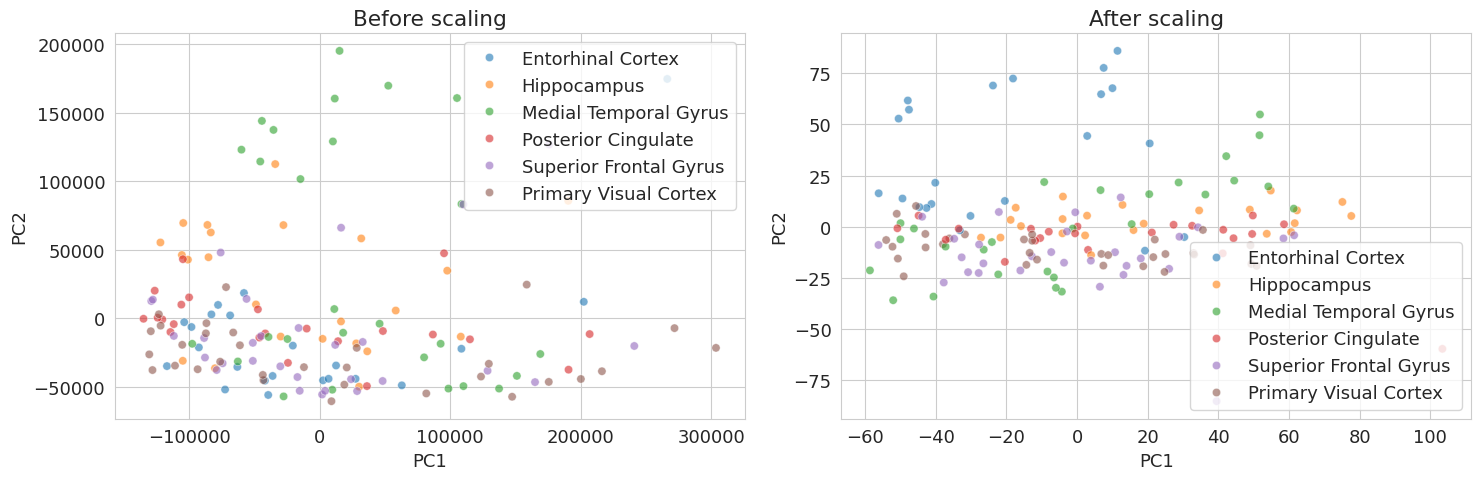

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, data, title in [(axes[0], expression_filtered.values, "Before scaling"), (axes[1], X, "After scaling")]:
    pca = PCA(n_components=2).fit_transform(data)
    sns.scatterplot(x=pca[:, 0], y=pca[:, 1], hue=metadata["region"].values, ax=ax, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


**Q2:** Which version shows clearer separation between brain regions?

---
## Exercise 3: PCA


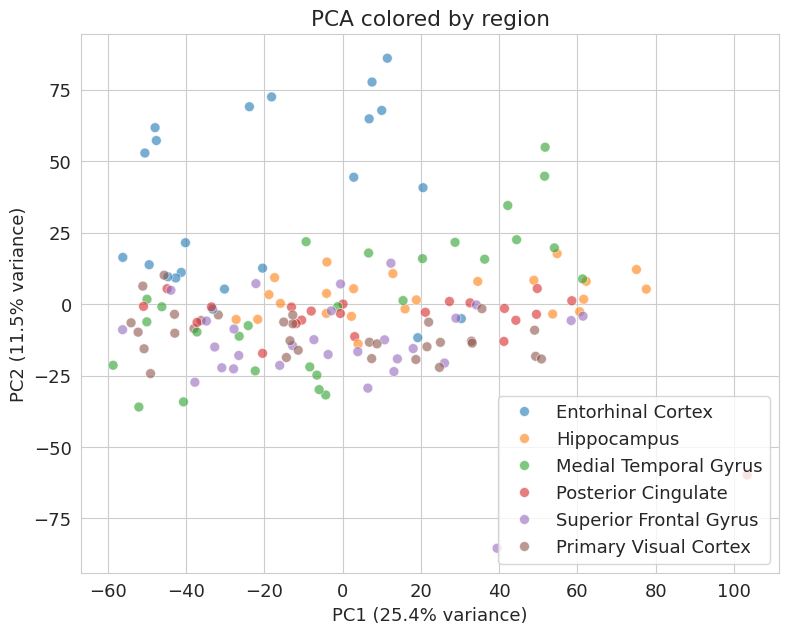

In [ ]:
# CHANGE... color_by: try "region", "disease", "sex", or "age"
# CHANGE... pc_x, pc_y: which components to plot (try 1 through 10)
color_by = "region"
pc_x = 1
pc_y = 2

pca = PCA(n_components=10).fit(X)
projected = pca.transform(X)

plt.figure(figsize=(9, 7))
if color_by == "age":
    sc = plt.scatter(projected[:, pc_x-1], projected[:, pc_y-1],
                     c=metadata["age_num"], cmap="coolwarm", alpha=0.6, s=50)
    plt.colorbar(sc, label="Age")
else:
    sns.scatterplot(x=projected[:, pc_x-1], y=projected[:, pc_y-1],
                    hue=metadata[color_by].values, alpha=0.6, s=50)

plt.xlabel(f"PC{pc_x} ({pca.explained_variance_ratio_[pc_x-1]:.1%} variance)")
plt.ylabel(f"PC{pc_y} ({pca.explained_variance_ratio_[pc_y-1]:.1%} variance)")
plt.title(f"PCA colored by {color_by}")
plt.show()


**Q3:** With color_by="region", do the brain regions separate? Now try "disease." Does AD vs control separate as clearly as region does? What does that tell you about what is driving the gene expression variation?

### How much info does each component hold?


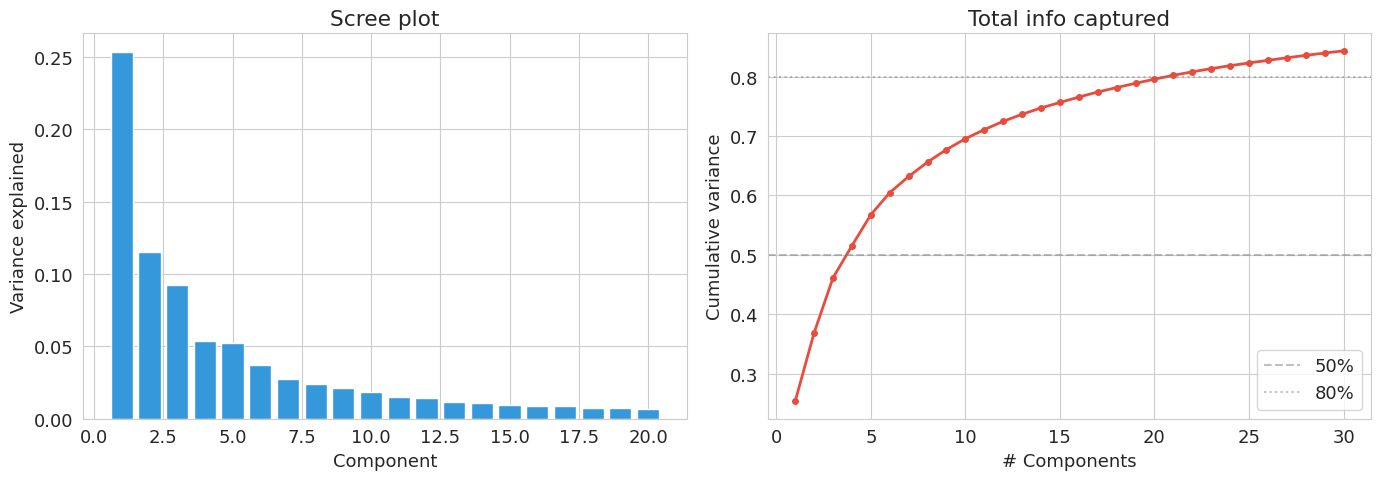

Need 21 components for 80% of variance across 5000 genes.


In [ ]:
pca_all = PCA(n_components=30).fit(X)
cumulative = np.cumsum(pca_all.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 21), pca_all.explained_variance_ratio_[:20], color="#3498db")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance explained")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, 31), cumulative, "o-", color="#e74c3c", linewidth=2, markersize=4)
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50%")
axes[1].axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="80%")
axes[1].set_xlabel("# Components"); axes[1].set_ylabel("Cumulative variance")
axes[1].set_title("Total info captured"); axes[1].legend()

plt.tight_layout()
plt.show()

n_80 = np.argmax(cumulative >= 0.80) + 1
print(f"Need {n_80} components for 80% of variance across {X.shape[1]} genes.")


### Which genes drive the separation?


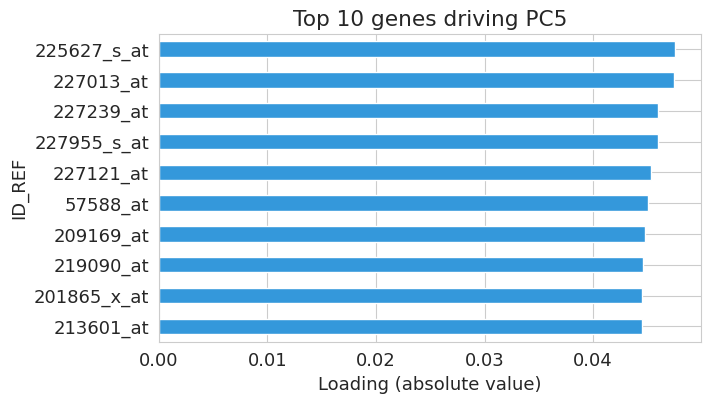

In [ ]:
# CHANGE... component: try 1, 2, 3, 4, 5
component = 1

loadings = pd.Series(pca_all.components_[component - 1], index=expression_filtered.columns)
top_genes = loadings.abs().nlargest(10)

top_genes.sort_values().plot.barh(figsize=(7, 4), color="#3498db")
plt.title(f"Top 10 genes driving PC{component}")
plt.xlabel("Loading (absolute value)")
plt.show()



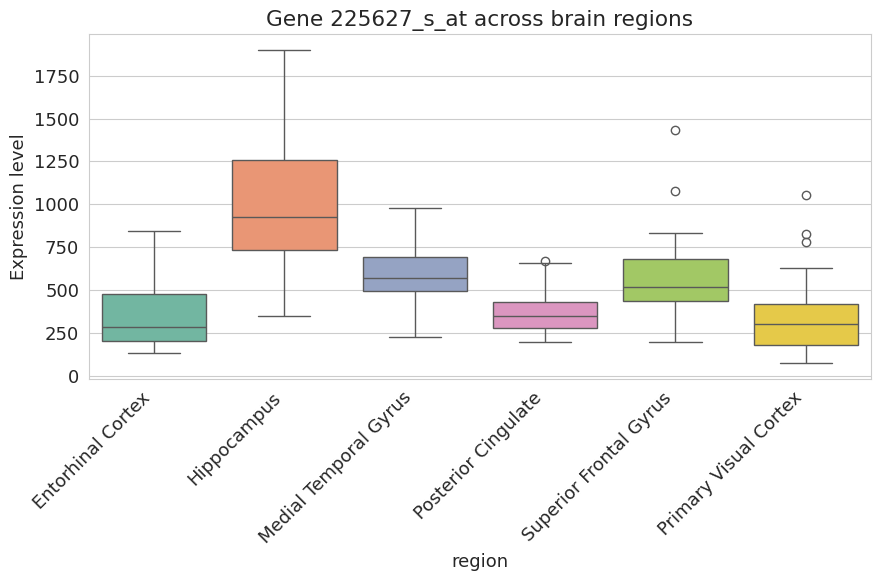

In [ ]:
# CHANGE... Pick a gene from the loadings plot above
gene = top_genes.index[0]   #enter the gene into the 0 slot here (0 through 9)

sns.boxplot(x="region", y=expression_filtered[gene].values, data=metadata, palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title(f"Gene {gene} across brain regions")
plt.ylabel("Expression level")
plt.tight_layout()
plt.show()



**Q4:** Is the top gene in PC1 actually expressed differently across brain regions?

---
## Exercise 4: K-Means Clustering


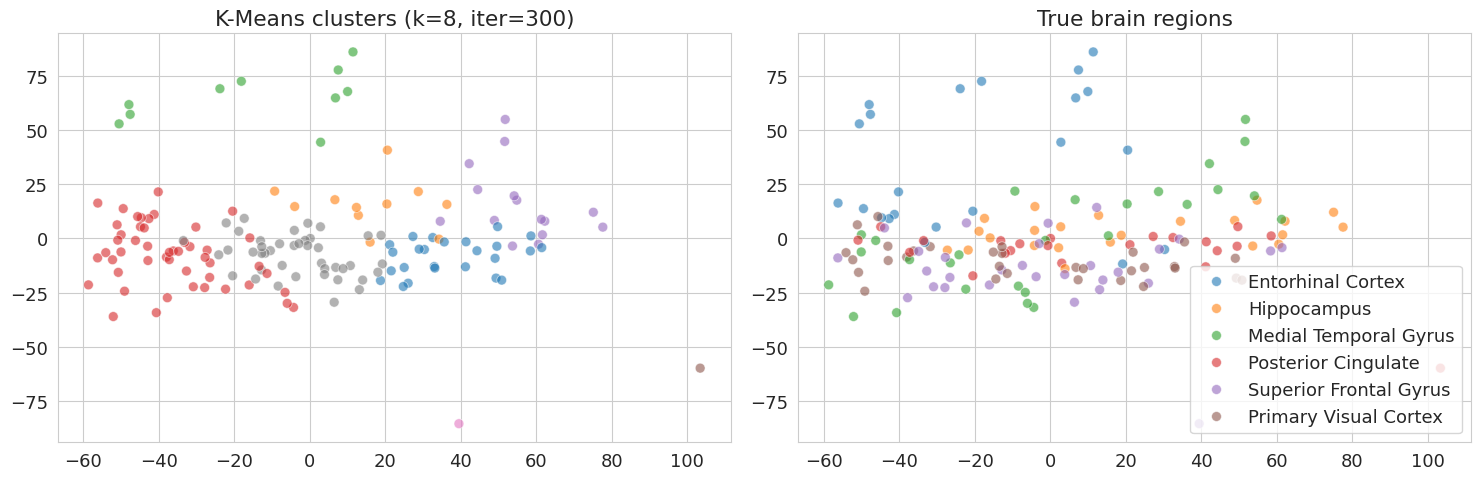

In [ ]:
### CHANGE the following:
# k: try 2, 3, 4, 5, 6, 8
# max_iter: try 1, 2, 5, 10, 50, 300
k = 8
max_iter = 300

pca2d = PCA(n_components=2).fit_transform(X)
kmeans = KMeans(n_clusters=k, max_iter=max_iter, random_state=42, n_init=1)
cluster_labels = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=pca2d[:, 0], y=pca2d[:, 1], hue=cluster_labels,
                palette="tab10", ax=axes[0], alpha=0.6, s=50, legend=False)
axes[0].set_title(f"K-Means clusters (k={k}, iter={max_iter})")

sns.scatterplot(x=pca2d[:, 0], y=pca2d[:, 1], hue=metadata["region"].values,
                ax=axes[1], alpha=0.6, s=50)
axes[1].set_title("True brain regions")

plt.tight_layout()
plt.show()


How do the clusters map to actual brain regions?


In [ ]:
pd.crosstab(cluster_labels, metadata["region"], margins=True)


region,Entorhinal Cortex,Hippocampus,Medial Temporal Gyrus,Posterior Cingulate,Primary Visual Cortex,Superior Frontal Gyrus,All
row_0,,,,,,,
0,1,0,0,9,8,5,23
1,1,7,8,4,11,11,42
2,11,0,0,0,0,0,11
3,0,6,1,7,1,2,17
4,9,1,9,2,11,11,43
5,0,9,9,0,0,0,18
All,22,23,27,22,31,29,154


**Q5:** Set max_iter=1, then 2, 5, 10, 300. When do the clusters stabilize?

**Q6:** With max_iter=300, try k=2 through 8. Is there a k where each cluster mostly contains one brain region? How does it compare to the actual number of regions (6)?

### The Elbow Method


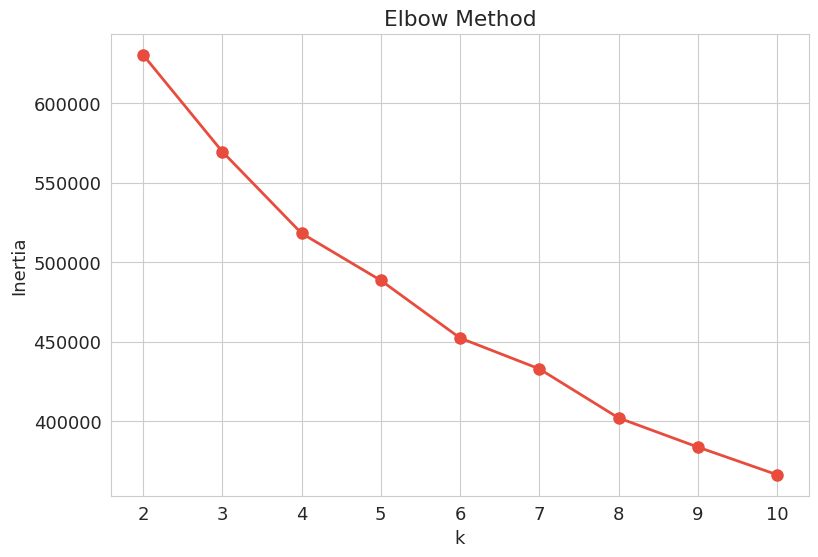

In [ ]:
inertias = []
for k_val in range(2, 11):
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias, "o-", linewidth=2, markersize=8, color="#e74c3c")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow Method")
plt.xticks(range(2, 11))
plt.show()


**Q7:** Where does the curve bend? Does it match 6 regions?

### Can K-Means find disease instead of region?


In [ ]:
### CHANGE... k: try 2, 3
k = 2

labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

print("Clusters vs brain region:")
print(pd.crosstab(labels, metadata["region"], margins=True).to_string())
print("\nClusters vs disease status:")
print(pd.crosstab(labels, metadata["disease"], margins=True).to_string())


Clusters vs brain region:
region  Entorhinal Cortex  Hippocampus  Medial Temporal Gyrus  Posterior Cingulate  Primary Visual Cortex  Superior Frontal Gyrus  All
row_0                                                                                                                                 
0                       8           12                     11                   10                     12                      11   64
1                      14           11                     16                   12                     19                      18   90
All                    22           23                     27                   22                     31                      29  154

Clusters vs disease status:
disease  Alzheimer's Disease  normal  All
row_0                                    
0                         13      51   64
1                         74      16   90
All                       87      67  154


**Q8:** With k=2, does k-means find AD vs control, or does it find something else (like a region split)?

---
## Exercise 5: t-SNE


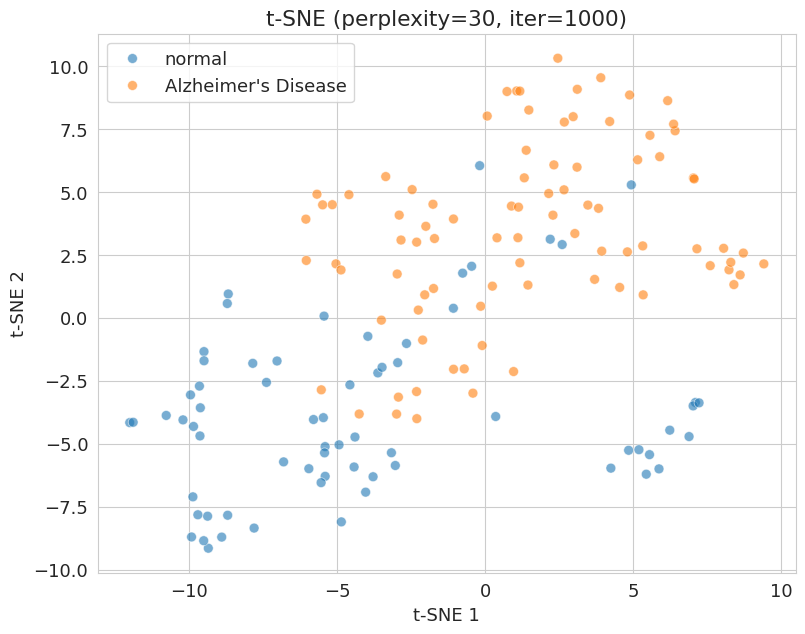

In [ ]:
### CHANGE the followin:
# perplexity: try 5, 15, 30, 50
# max_iter: try 250, 500, 1000, 5000
# color_by: try "region", "disease", "sex", "age"
perplexity = 30
max_iter = 1000
color_by = "disease"

tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=max_iter, random_state=42)
tsne_result = tsne.fit_transform(X)

plt.figure(figsize=(9, 7))
if color_by == "age":
    sc = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=metadata["age_num"],
                     cmap="coolwarm", alpha=0.6, s=50)
    plt.colorbar(sc, label="Age")
else:
    sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1],
                    hue=metadata[color_by].values, alpha=0.6, s=50)

plt.title(f"t-SNE (perplexity={perplexity}, iter={max_iter})")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.show()


**Q9:** Set max_iter=250, then 1000, then 5000. When does it stabilize?

**Q10:** Compare perplexity=5 vs 50. What happens to the clusters?

**Q11:** Color by "disease." Can you see AD vs control separating?

---
## Exercise 6: UMAP


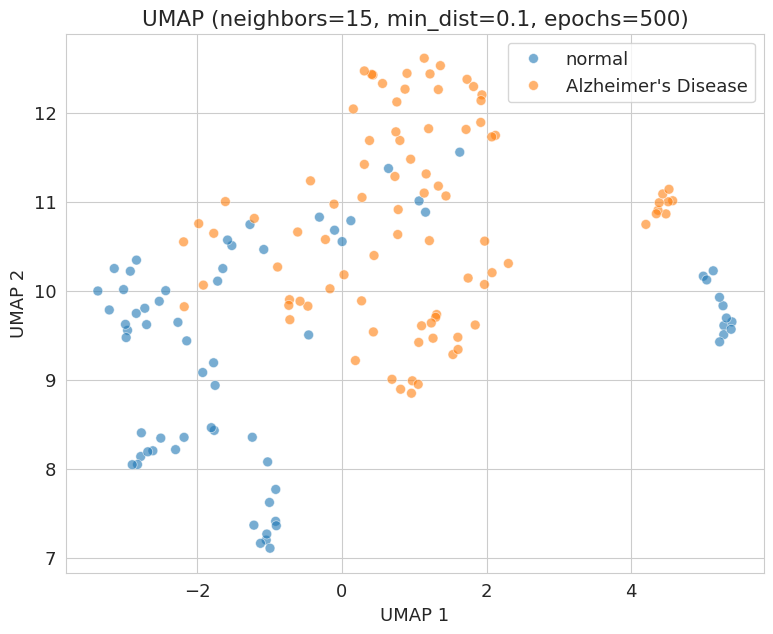

In [ ]:
import umap

### CHANGE the following:
# n_neighbors: try 5, 15, 30, 50, 100
# min_dist: try 0.0, 0.1, 0.5, 0.8
# n_epochs: try 50, 200, 500
# color_by: try "region", "disease", "sex", "age"
n_neighbors = 15
min_dist = 0.1
n_epochs = 500
color_by = "disease"

umap_model = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                        n_epochs=n_epochs, random_state=42)
umap_result = umap_model.fit_transform(X)

plt.figure(figsize=(9, 7))
if color_by == "age":
    sc = plt.scatter(umap_result[:, 0], umap_result[:, 1], c=metadata["age_num"],
                     cmap="coolwarm", alpha=0.6, s=50)
    plt.colorbar(sc, label="Age")
else:
    sns.scatterplot(x=umap_result[:, 0], y=umap_result[:, 1],
                    hue=metadata[color_by].values, alpha=0.6, s=50)

plt.title(f"UMAP (neighbors={n_neighbors}, min_dist={min_dist}, epochs={n_epochs})")
plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
plt.show()


**Q12:** Set n_epochs=50. Then try 200 and then 500. When does it stabilize?

**Q13:** Compare n_neighbors=5 vs 100. What happens to the clusters?

**Q14:** Compare min_dist=0.0 vs 0.8. What changes?

**Q15:** Color by "disease." Do AD and control separate within the same brain region?

---
## Exercise 7: Combining methods


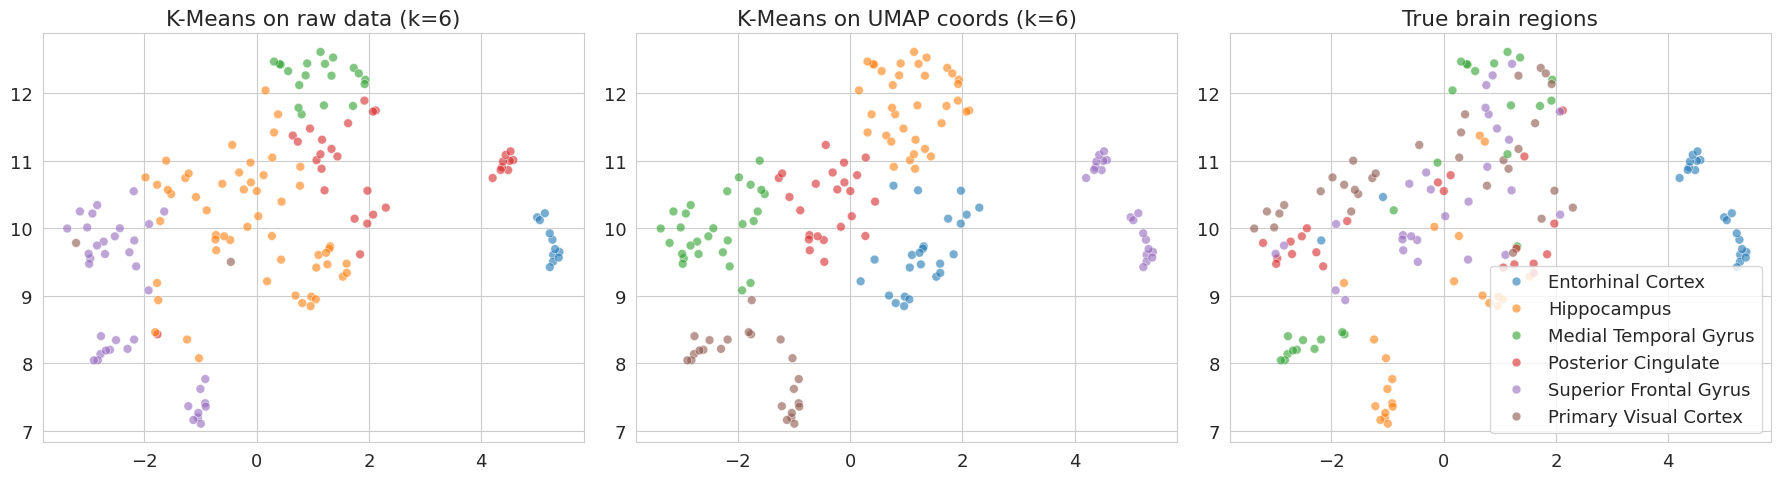

K-Means on raw data:
region  Entorhinal Cortex  Hippocampus  Medial Temporal Gyrus  Posterior Cingulate  Primary Visual Cortex  Superior Frontal Gyrus
row_0                                                                                                                            
0                      11            0                      0                    0                      0                       0
1                       1           12                      5                    9                     13                      14
2                       0            0                     10                    0                      4                       5
3                       9            2                      3                    4                      7                       5
4                       1            9                      9                    8                      7                       4
5                       0            0                      0        

In [ ]:
### CHANGE... k: try 2, 3, 4, 5, 6, 8
k = 6

umap_emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

km_raw = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
km_umap = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(umap_emb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=umap_emb[:, 0], y=umap_emb[:, 1], hue=km_raw,
                palette="tab10", ax=axes[0], alpha=0.6, s=40, legend=False)
axes[0].set_title(f"K-Means on raw data (k={k})")

sns.scatterplot(x=umap_emb[:, 0], y=umap_emb[:, 1], hue=km_umap,
                palette="tab10", ax=axes[1], alpha=0.6, s=40, legend=False)
axes[1].set_title(f"K-Means on UMAP coords (k={k})")

sns.scatterplot(x=umap_emb[:, 0], y=umap_emb[:, 1], hue=metadata["region"].values,
                ax=axes[2], alpha=0.6, s=40)
axes[2].set_title("True brain regions")

plt.tight_layout()
plt.show()

print("K-Means on raw data:")
print(pd.crosstab(km_raw, metadata["region"]).to_string())
print("\nK-Means on UMAP:")
print(pd.crosstab(km_umap, metadata["region"]).to_string())


**Q16:** Does the clustering on UMAP coordinates match the brain regions better than the clustering on raw data?

---
## Exercise 8: Final comparison


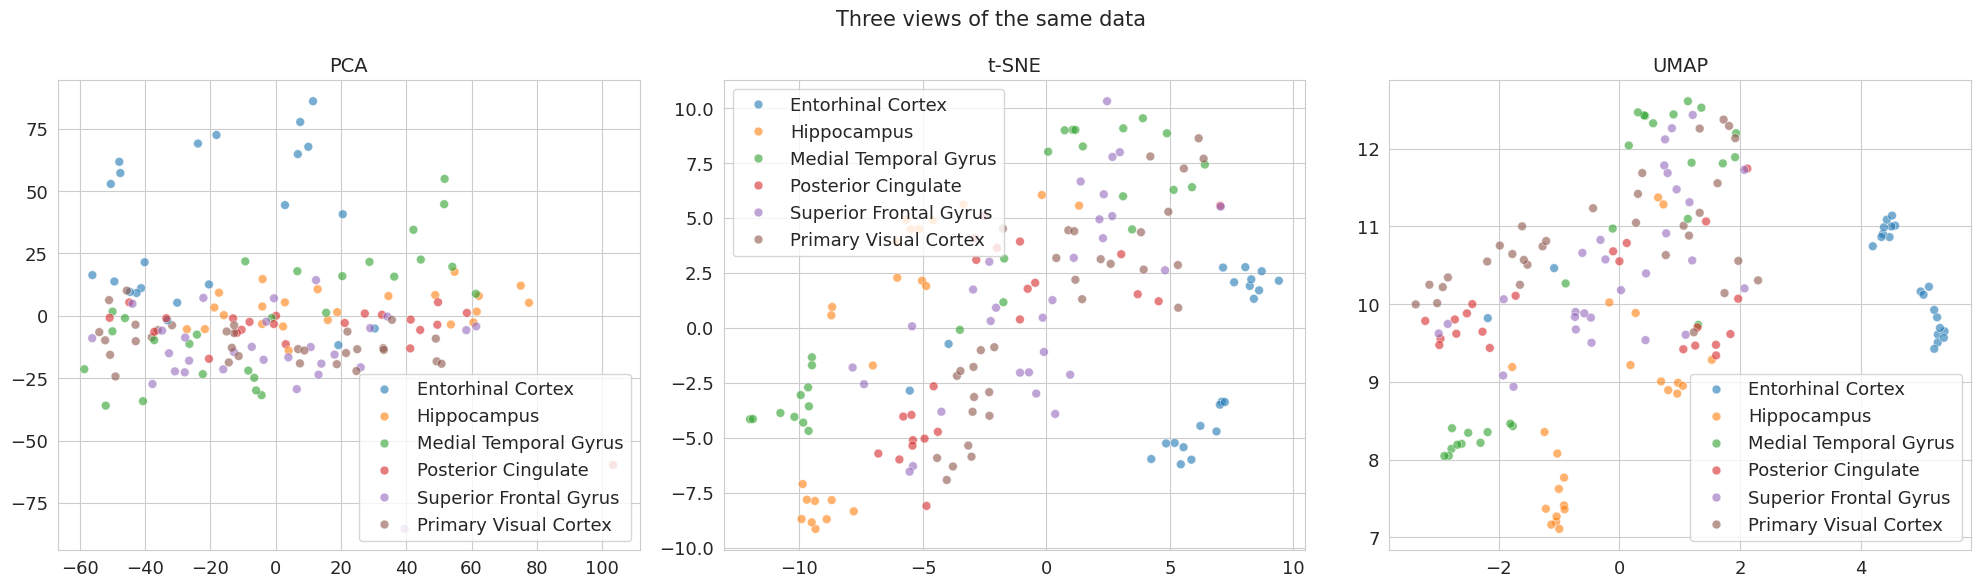

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA
pca_2d = PCA(n_components=2).fit_transform(X)
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=metadata["region"].values,
                ax=axes[0], alpha=0.6, s=40)
axes[0].set_title("PCA", fontsize=14)

# t-SNE
tsne_2d = TSNE(n_components=2, random_state=42).fit_transform(X)
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=metadata["region"].values,
                ax=axes[1], alpha=0.6, s=40)
axes[1].set_title("t-SNE", fontsize=14)

# UMAP
umap_2d = umap.UMAP(random_state=42).fit_transform(X)
sns.scatterplot(x=umap_2d[:, 0], y=umap_2d[:, 1], hue=metadata["region"].values,
                ax=axes[2], alpha=0.6, s=40)
axes[2].set_title("UMAP", fontsize=14)

plt.suptitle("Three views of the same data", fontsize=15)
plt.tight_layout()
plt.show()


---
## Discussion

**Q17:** Brain regions separated clearly. Disease status didn't. Why might that be? What does that tell you about the biological signal that each variable produces?

**Q18:** When you set k=2 in k-means, did it find AD vs control or did it find a region-based split? What does that tell you about what is dominant in the data?

**Q19:** PCA lets you trace back to specific genes through the loadings. t-SNE and UMAP don't. When would you pick one over the other?

**Q20:** If you were trying to find genes that differ in Alzheimer's disease, would you look at the whole dataset at once or analyze each brain region separately? Why?

**Q21:** In our lab, we apply these same methods to human blood samples. Blood-based data doesn't separate nearly as cleanly as brain tissue, because the disease signal in blood is much subtler. Biologically, why do you think this is so? Computationally, what methods could you use when the groups overlap?


---
*Data: NIH Dataset [GSE5281](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE5281), Liang et al. 2007.*
